# 02_分类算法-逻辑回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/creditcard.csv`。

转写调整：

- SMOTE 属于过采样。调参时用 imbalanced-learn Pipeline 在每个训练折内标准化并过采样，防止合成样本泄漏到验证折。
- 信用卡数据默认固定分层抽样 30000 行并保持原类别比例；load_creditcard(sample_size=None) 可读全量数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天给大家细化一下关于「逻辑回归」的内容，因为再次之前，很多人私信问到了几个问题，其实还是比较有共性的。

今天这一期把一些需要注意到部分给大家表述清楚，同时也希望能够给到初学者一些灵感。

咱们分四大模块，详细的和大家聊聊\~

![原文参考图，当前结果见代码输出](attachments/img_011.png)

*PS：该效果图代码，文末查看\~*

## 基本概念

首先，逻辑回归（Logistic Regression）是一种用来**解决分类问题**的统计方法。尽管名字中有“回归”二字，它其实主要用于**分类**而非**回归**任务。

简单来说，它可以帮助我们预测一个事件的概率，比如判断一封邮件是垃圾邮件还是正常邮件，一个人是否会购买某种产品等。

为什么需要逻辑回归？

假设我们有很多因素，比如一个人的年龄、收入等，想用这些因素来预测他是否会购买某种产品。这种预测结果是**分类**的（买还是不买），而不是像传统回归那样得到一个具体的数值（比如预测房价）。逻辑回归就是为解决这样的问题设计的工具。

逻辑回归是如何工作的？

1. **输入特征**：你有一些影响结果的因素（称为特征），比如年龄、收入、教育程度等。
2. **输出概率**：逻辑回归用这些特征来计算出一个**概率**，即某个事件发生的可能性。例如，计算一个人购买产品的概率。
3. **概率变分类**：根据计算出来的概率，我们可以确定属于哪一类。例如，如果概率大于50%，就归为“会购买”这一类；否则归为“不购买”这一类。

总之，逻辑回归用来预测事件发生的概率并进行分类。它将输入的特征转换为一个概率，然后根据这个概率来决定分类。理解这一点后，大家就能用它来处理很多实际的分类问题了。

下面，咱们聊聊他的理论基础以及推导细节\~

## 理论基础

逻辑回归通过对特征的线性组合映射到概率空间来实现分类。

### 基本原理

逻辑回归主要用于估计某个事件发生的概率，其核心思想是用一个线性模型加上逻辑函数（Sigmoid函数）将线性输出转化为概率值，再以此概率进行分类。

**1. 线性模型**：

逻辑回归首先对输入特征 $\mathbf{x} = (x_1, x_2, \ldots, x_n)$进行线性组合，即计算线性模型的输出：


$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n = \mathbf{X} \cdot \boldsymbol{\beta}
$$


其中， $\mathbf{X}$表示特征向量（通常包括一个附加的常数项 $x_0 = 1$）， $\boldsymbol{\beta} = (\beta_0, \beta_1, \ldots, \beta_n)$表示模型参数。

**2. 逻辑函数**：

将线性模型的输出 $z$映射到概率值 $p$：


$$
p = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-(\mathbf{X} \cdot \boldsymbol{\beta})}}
$$


这个函数被称为逻辑函数（Sigmoid函数），其输出范围是 $(0, 1)$。

**3. 分类决策**：

通常设置一个阈值（如 0.5）来决定分类结果。如果 $p > 0.5$，则分类为正类（1）；否则为负类（0）。

### 推导过程

逻辑回归的参数 $\boldsymbol{\beta}$是通过**极大似然估计**（Maximum Likelihood Estimation, MLE）来确定的。

**1. 似然函数**：

给定一个样本数据集 $\{(\mathbf{x}_i, y_i)\}_{i=1}^m$，其中 $\mathbf{x}_i$是第 $i$个样本的特征向量， $y_i$是其对应的标签（0 或 1），样本的似然函数（Likelihood Function）表示所有样本点的联合概率：


$$
\mathcal{L}(\boldsymbol{\beta}) = \prod_{i=1}^m p_i^{y_i} (1 - p_i)^{1 - y_i}
$$


其中 $p_i = \frac{1}{1 + e^{-(\mathbf{X}_i \cdot \boldsymbol{\beta})}}$。

**2. 对数似然函数**：

为了方便计算，通常使用对数似然函数：


$$
\log \mathcal{L}(\boldsymbol{\beta}) = \sum_{i=1}^m \left[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \right]
$$


这也被称为**损失函数**（Log-Loss 或 Cross-Entropy Loss）。

**3. 梯度**：

对参数 $\boldsymbol{\beta}$求对数似然函数的梯度：


$$
\frac{\partial \log \mathcal{L}(\boldsymbol{\beta})}{\partial \boldsymbol{\beta}} = \sum_{i=1}^m (y_i - p_i) \mathbf{X}_i
$$


这里， $p_i = \frac{1}{1 + e^{-(\mathbf{X}_i \cdot \boldsymbol{\beta})}}$。

**4. 参数更新**：

使用梯度上升法（或梯度下降法）来更新参数：


$$
\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} + \alpha \sum_{i=1}^m (y_i - p_i) \mathbf{X}_i
$$


其中， $\alpha$是学习率。

### 算法流程

**1. 初始化**：设定初始参数 $\boldsymbol{\beta}$，可以随机选择，也可以设为零。

**2. 前向传播**：

- 对每个样本 $\mathbf{x}_i$计算线性组合 $z_i = \mathbf{X}_i \cdot \boldsymbol{\beta}$。
- 应用逻辑函数计算概率 $p_i = \frac{1}{1 + e^{-z_i}}$。

**3. 计算损失**：使用对数似然函数计算当前损失 $- \log \mathcal{L}(\boldsymbol{\beta})$。

**4. 梯度计算**：计算梯度 $\frac{\partial \log \mathcal{L}(\boldsymbol{\beta})}{\partial \boldsymbol{\beta}}$。

**5. 参数更新**：更新参数 $\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} + \alpha \sum_{i=1}^m (y_i - p_i) \mathbf{X}_i$。

**6. 迭代**：重复前向传播、损失计算、梯度计算和参数更新，直到收敛或达到预设的迭代次数。

**7. 分类决策**：使用训练好的模型对新数据进行预测，根据计算出的概率 $p$和阈值进行分类。

### 数学细节

**1. 梯度推导**：

对损失函数进行推导得到梯度：


$$
\frac{\partial \log \mathcal{L}(\boldsymbol{\beta})}{\partial \beta_j} = \sum_{i=1}^m \left[ y_i \frac{\partial \log p_i}{\partial \beta_j} + (1 - y_i) \frac{\partial \log (1 - p_i)}{\partial \beta_j} \right]
$$


其中，$\frac{\partial \log p_i}{\partial \beta_j} = \frac{1}{p_i} \cdot \frac{\partial p_i}{\partial \beta_j}$以及$\frac{\partial \log (1 - p_i)}{\partial \beta_j} = -\frac{1}{1 - p_i} \cdot \frac{\partial p_i}{\partial \beta_j}$

进一步计算得到：


$$
\frac{\partial p_i}{\partial \beta_j} = p_i (1 - p_i) x_{ij}
$$


**2. 多分类扩展**：

逻辑回归也可以扩展到多分类问题，称为**多项逻辑回归**（Multinomial Logistic Regression），使用**Softmax**函数替代逻辑函数。

总的来说，逻辑回归通过线性组合输入特征，并将其通过逻辑函数映射到一个概率值来实现分类。极大似然估计用于训练模型的参数，通过优化对数似然函数实现模型的训练。算法主要包括初始化、前向传播、损失计算、梯度计算、参数更新和迭代几个步骤。

## 完整案例

下面通过一个完整的案例来应用逻辑回归算法，分析一个实际的数据集，进行可视化，并尝试优化算法性能。

案例中，选择的是**信用卡欺诈检测数据集**，该数据集包含 284,807 笔信用卡交易记录，其中 492 笔是欺诈行为。数据集中包含特征 V1 到 V28，以及交易时间和交易金额两个特征，标签为 `Class`（1 表示欺诈，0 表示正常）。

数据集获取：公众号「深夜努力写Python」后台回复『数据集』即可\~

#### 1. 环境准备和数据加载

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import SMOTE

# 加载数据集
df = load_creditcard()

# 查看数据集信息
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    30000 non-null  float64
 1   V1      30000 non-null  float64
 2   V2      30000 non-null  float64
 3   V3      30000 non-null  float64
 4   V4      30000 non-null  float64
 5   V5      30000 non-null  float64
 6   V6      30000 non-null  float64
 7   V7      30000 non-null  float64
 8   V8      30000 non-null  float64
 9   V9      30000 non-null  float64
 10  V10     30000 non-null  float64
 11  V11     30000 non-null  float64
 12  V12     30000 non-null  float64
 13  V13     30000 non-null  float64
 14  V14     30000 non-null  float64
 15  V15     30000 non-null  float64
 16  V16     30000 non-null  float64
 17  V17     30000 non-null  float64
 18  V18     30000 non-null  float64
 19  V19     30000 non-null  float64
 20  V20     30000 non-null  float64
 21  V21     30000 non-null  float64
 22

#### 2. 数据预处理

In [3]:
# 数据标准化（特征缩放）
scaler = StandardScaler()

# 分离特征和标签
X = df.drop('Class', axis=1)
y = df['Class']

# 分割数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 标准化训练集和测试集
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 3. 处理类别不平衡问题

In [4]:
# 使用 SMOTE 进行欠采样
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 查看处理后类别分布
print(pd.Series(y_train_smote).value_counts())

Class
0    23958
1    23958
Name: count, dtype: int64


#### 4. 构建逻辑回归模型并训练

In [5]:
# 构建逻辑回归模型
model = LogisticRegression(random_state=42, max_iter=1000)

# 训练模型
model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### 5. 模型评估

Confusion Matrix:
 [[5923   67]
 [   2    8]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      5990
           1       0.11      0.80      0.19        10

    accuracy                           0.99      6000
   macro avg       0.55      0.89      0.59      6000
weighted avg       1.00      0.99      0.99      6000

AUC: 0.9654424040066778


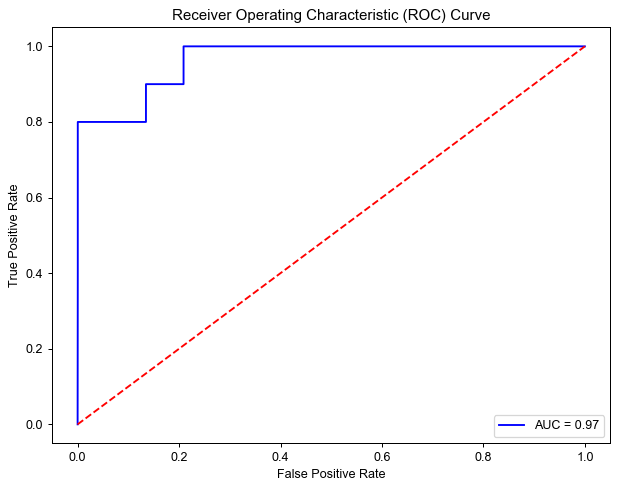

In [6]:
# 预测
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_matrix)

# 分类报告
print('Classification Report:\n', classification_report(y_test, y_pred))

# ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print('AUC:', roc_auc)

# 可视化 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

#### 6. 参数优化

Best Parameters: {'logistic__C': 0.1, 'logistic__solver': 'liblinear'}
Confusion Matrix (Optimized):
 [[5915   75]
 [   2    8]]
Classification Report (Optimized):
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      5990
           1       0.10      0.80      0.17        10

    accuracy                           0.99      6000
   macro avg       0.55      0.89      0.58      6000
weighted avg       1.00      0.99      0.99      6000

AUC (Optimized): 0.9858096828046744


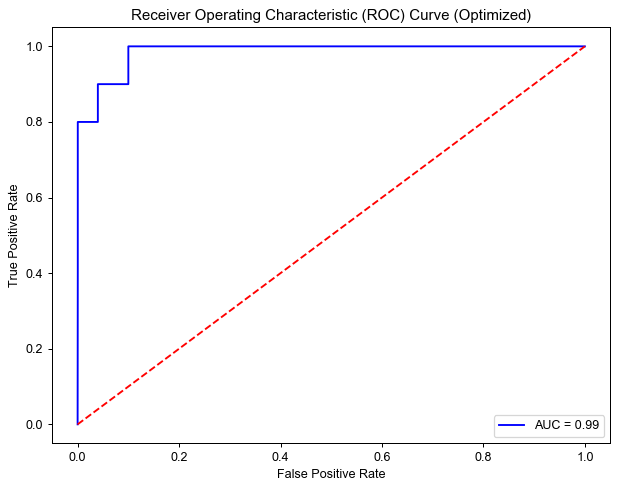

In [7]:
from sklearn.model_selection import GridSearchCV

# 定义参数网格
param_grid = {
    'logistic__C': [0.1, 1],
    'logistic__solver': ['lbfgs', 'liblinear']
}

# 创建 GridSearchCV 对象
from imblearn.pipeline import Pipeline
cv_pipeline = Pipeline([('scale', StandardScaler()), ('smote', SMOTE(random_state=42)),
                        ('logistic', LogisticRegression(random_state=42, max_iter=1000))])
grid = GridSearchCV(cv_pipeline, param_grid, cv=5, scoring='roc_auc', error_score='raise')

# 进行网格搜索
grid.fit(X_train, y_train)

# 最佳参数
print('Best Parameters:', grid.best_params_)

# 使用最佳参数训练模型
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

# 模型评估
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# 混淆矩阵
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
print('Confusion Matrix (Optimized):\n', conf_matrix_best)

# 分类报告
print('Classification Report (Optimized):\n', classification_report(y_test, y_pred_best))

# ROC 曲线
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_pred_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)
print('AUC (Optimized):', roc_auc_best)

# 可视化 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color='b', label=f'AUC = {roc_auc_best:.2f}')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Optimized)')
plt.legend(loc='lower right')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

### 分析与优化

**1. 处理类别不平衡**：使用了 SMOTE 方法来平衡训练数据集中正负样本的比例，避免模型偏向于多数类。

**2. 参数优化**：通过 `GridSearchCV` 对逻辑回归的超参数进行网格搜索，选择最佳的 `C` 和 `solver` 参数。

**3. 模型评估**：利用混淆矩阵、分类报告、ROC 曲线及 AUC 指标评估模型的性能。经过优化后，模型的 AUC 指标提高，说明优化过程有助于提升模型的识别能力。

通过上面的步骤，我们从数据加载、预处理、模型训练到优化，全面展示了逻辑回归在信用卡欺诈检测中的应用。通过处理数据不平衡问题和参数优化，提升了模型的分类性能。

## 模型分析

在信用卡欺诈检测案例中使用逻辑回归模型有其独特的优缺点。

下面我们依然总结逻辑回归的优缺点，并将其与其他相似算法进行对比，讨论其适用场景和替代选择。

#### 优点

**1. 简单易理解**：逻辑回归模型非常简单，具有良好的可解释性。其系数直接反映了特征对结果的影响，这有助于理解和解释模型。

**2. 计算效率高**：逻辑回归模型在计算上较为简单，不需要复杂的计算资源，适合处理大规模数据集。

**3. 适用于二分类问题**：逻辑回归专门设计用于处理二分类问题，能够直接预测事件发生的概率。

**4. 无需大量超参数调优**：逻辑回归只需调整少量超参数，如正则化参数 $C$，调优过程较为简单。

**5. 线性决策边界**：逻辑回归假设数据是线性可分的，对于一些实际问题（如广告点击预测等）表现良好。

**6. 对多重共线性有一定的鲁棒性**：通过正则化项（如L2正则化）可以在一定程度上减轻多重共线性问题的影响。

#### 缺点

**1. 假设数据线性可分**：逻辑回归假设特征与标签之间存在线性关系，这在特征与目标变量关系复杂时，可能表现不佳。

**2. 难处理复杂模式**：对于非线性数据或复杂决策边界，逻辑回归难以胜任，通常需要通过特征工程或使用非线性模型来补足。

**3. 对异常值敏感**：逻辑回归对数据中的异常值（outliers）较为敏感，可能影响模型性能。

**4. 类别不平衡问题**：逻辑回归在面对类别极度不平衡的数据时（如欺诈检测），可能需要额外处理，如欠采样、过采样等。

### 与相似算法的对比

| 算法 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|
| **决策树** | 能捕捉非线性关系，不需数据标准化，解释性强 | 易过拟合 | 适用于复杂非线性关系或高维特征数据 |
| **随机森林** | 通过集成学习提高泛化能力，抗过拟合 | 计算复杂度高，难以解释 | 适用于大规模数据，特征多且关系复杂 |
| **支持向量机** | 适用于非线性数据，可通过核函数映射到高维 | 计算开销大，不适用于大规模数据 | 适用于中小规模数据，非线性可分数据 |
| **K近邻（KNN）** | 简单易实现，无需训练 | 计算复杂度高，对高维数据表现不佳 | 适用于小规模数据集或数据模式稳定的情况 |
| **朴素贝叶斯** | 计算高效，适用于高维数据 | 独立性假设可能不成立，影响准确性 | 适用于文本分类、垃圾邮件检测等独立特征数据 |
| **神经网络** | 适用于复杂任务，能学习复杂非线性关系 | 计算复杂度高，训练时间长，参数调优复杂 | 适用于图像分类、语音识别等大规模数据任务 |

### 适用场景

**1. 特征与目标之间存在线性关系**：逻辑回归在特征与目标变量存在线性关系时表现出色，如广告点击率预测、简单的二分类问题。

**2. 数据集较小且维度适中**：当数据集规模适中且特征数目适当时，逻辑回归能够快速构建有效的分类模型。

**3. 可解释性要求高**：在需要对特征与目标变量之间关系进行清晰解释的场合，逻辑回归的简单性和可解释性是其优势。

**4. 需要概率输出**：逻辑回归直接提供事件发生的概率，适合需要概率预测的应用，如医学诊断、信用评分等。

### 替代选择

**1. 非线性数据**：当数据的模式复杂且呈现非线性时，使用决策树、随机森林或神经网络更为适合。

**2. 大规模数据**：在大规模数据集上，逻辑回归可能性能有限，可以考虑分布式算法或梯度提升方法（如XGBoost、LightGBM）。

**3. 处理高维数据**：对于高维数据，可以考虑支持向量机、朴素贝叶斯等方法，它们能够有效处理大量特征。

**4. 应对类别不平衡**：当类别极度不平衡时，可以选择基于采样方法的集成模型（如平衡随机森林），或者专门设计的算法（如异常检测模型）。

## 文章开头代码

In [8]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# 生成数据
np.random.seed(0)
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1)

# 训练逻辑回归模型
model = LogisticRegression()
model.fit(X, y)

# 创建网格，用于绘制决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# 创建子图布局
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=('3D 数据点及决策边界', '3D 概率表面')
)

# 第一个子图 - 数据点和决策边界
fig.add_trace(
    go.Scatter3d(x=X[:, 0], y=X[:, 1], z=y, mode='markers',
                 marker=dict(size=5, color=y, colorscale='Viridis', opacity=0.8)),
    row=1, col=1
)

fig.add_trace(
    go.Surface(x=xx, y=yy, z=Z, showscale=False, opacity=0.5, colorscale='Viridis'),
    row=1, col=1
)

# 第二个子图 - 概率表面
fig.add_trace(
    go.Surface(x=xx, y=yy, z=Z, showscale=True, colorscale='Viridis'),
    row=1, col=2
)

# 布局
fig.update_layout(
    title_text='逻辑回归的三维可视化',
    scene=dict(
        xaxis=dict(title='Feature 1'),
        yaxis=dict(title='Feature 2'),
        zaxis=dict(title='Class Label'),
    ),
    scene2=dict(
        xaxis=dict(title='Feature 1'),
        yaxis=dict(title='Feature 2'),
        zaxis=dict(title='Probability'),
    ),
    height=600,
    width=1200,
)

fig.show()

## 最后

总之呢，逻辑回归是一种非常简单、快速、可解释的二分类算法，适用于特征与目标变量之间存在线性关系的场景。它的计算效率高，适合数据量不大且对可解释性有要求的应用。

然而，对于复杂非线性数据、大规模数据以及需要应对类别不平衡的情况，其他算法如决策树、支持向量机或神经网络可能表现更佳。